In [95]:
import io

import matplotlib.pyplot as plt
import numpy as np
import tensorstore as ts
from mpl_toolkits.axes_grid1 import ImageGrid

In [103]:
output_path = "/groups/saalfeld/saalfeldlab/zapbench-processed/20251007"
output_uri = f"file://{output_path}"


with np.load(
      f"{output_path}/per_cell_z_data.npz",
      allow_pickle=False,
  ) as fin:
  cell_id = fin["cell_id"][:]
  z_cell = fin["z_cell"][:]
  num_pxs = fin["num_pxs"][:]

# with np.load(
#       f"{output_path}/timestamps_ms.npz",
#       allow_pickle=False,
#   ) as fin:
#   timestamps_ms = fin["timestamps_ms"][:]


In [104]:
# TEMPORARY: data hasn't finished processing yet
MAX_TIME_STEPS = 7000

In [105]:
ds = ts.open({
    'open': True,
    'driver': 'zarr3',
    'kvstore': f'{output_uri}/cell_z_activity.zarr'
}).result()
# compare first MAX_TIME_STEPS time points
traces = ds[:MAX_TIME_STEPS, :].read().result()

## Check that our traces agree with official zapbench traces

In [106]:
ds = ts.open({
    'open': True,
    'driver': 'zarr3',
    'kvstore': 'gs://zapbench-release/volumes/20240930/traces'
}).result()
traces_official = ds[:MAX_TIME_STEPS, :].read().result()

In [107]:
traces.shape

(7000, 169133)

In [108]:
px_per_cell = np.bincount(cell_id, weights=num_pxs)
traces_agg = np.zeros((MAX_TIME_STEPS, px_per_cell.shape[0]))
for t in range(MAX_TIME_STEPS):
  traces_agg[t, :] = np.bincount(cell_id, weights=traces[t]*num_pxs) / px_per_cell

In [109]:
assert np.allclose(traces_agg, traces_official, atol=1e-4)

## Check time stamps

In [110]:
ds = ts.open({
    'open': True,
    'driver': 'zarr3',
    'kvstore': f'{output_uri}/cell_z_time_ms.zarr'
}).result()
# compare first MAX_TIME_STEPS time points
cellz_time_ms = ds[:MAX_TIME_STEPS, :].read().result()

In [111]:
lowest_time_ms = cellz_time_ms.min(axis=1)
highest_time_ms = cellz_time_ms.max(axis=1)

# Make sure we haven't scrambled time stamp assignment.
# The gap between two official time points is 914 ms.
assert (highest_time_ms < lowest_time_ms + 914).all()

In [112]:
# `ts_agg` is the pixel-weighted mean wall time point for each cell
px_per_cell = np.bincount(cell_id, weights=num_pxs)
ts_agg = np.zeros((MAX_TIME_STEPS, px_per_cell.shape[0]))
for t in range(MAX_TIME_STEPS):
  ts_agg[t, :] = np.bincount(cell_id, weights=cellz_time_ms[t]*num_pxs) / px_per_cell

In [113]:
# this is the cell whose recording starts at the lowest wall time point
# we will linearly interpolate traces to match this cell
ref_time_cell = np.argmin(ts_agg[0])
ts_agg[:, ref_time_cell]


#chatgpt generated code
def align_traces_to_reference(values, times, ref_idx):
    """
    Linearly interpolate all traces (columns) to match the time points
    of the reference trace (column ref_idx). When interpolation is not
    possible, output NaN.

    Parameters
    ----------
    values : np.ndarray
        Array of shape (n_timepoints, n_traces).
    times : np.ndarray
        Array of shape (n_timepoints, n_traces) with time points for each trace.
    ref_idx : int
        Index of the reference trace (column) to align others to.

    Returns
    -------
    aligned : np.ndarray
        Array of shape (len(times), n_traces) with aligned traces.
    """
    ref_t = times[:, ref_idx]
    n_traces = values.shape[1]
    aligned = np.full((len(ref_t), n_traces), np.nan, dtype=np.float64)

    for j in range(n_traces):
        t = times[:, j]
        v = values[:, j]

        # Mask out NaNs or invalid points
        mask = np.isfinite(t) & np.isfinite(v)
        if np.count_nonzero(mask) < 2:
            continue  # Not enough points to interpolate

        # Ensure monotonic order (np.interp requires ascending x)
        order = np.argsort(t[mask])
        tt = t[mask][order]
        vv = v[mask][order]

        # Interpolate to reference times
        try:
            aligned[:, j] = np.interp(ref_t, tt, vv, left=np.nan, right=np.nan)
        except Exception:
            pass  # keep NaNs if interpolation fails

    return aligned

interp = align_traces_to_reference(traces_agg, ts_agg, ref_idx=ref_time_cell)

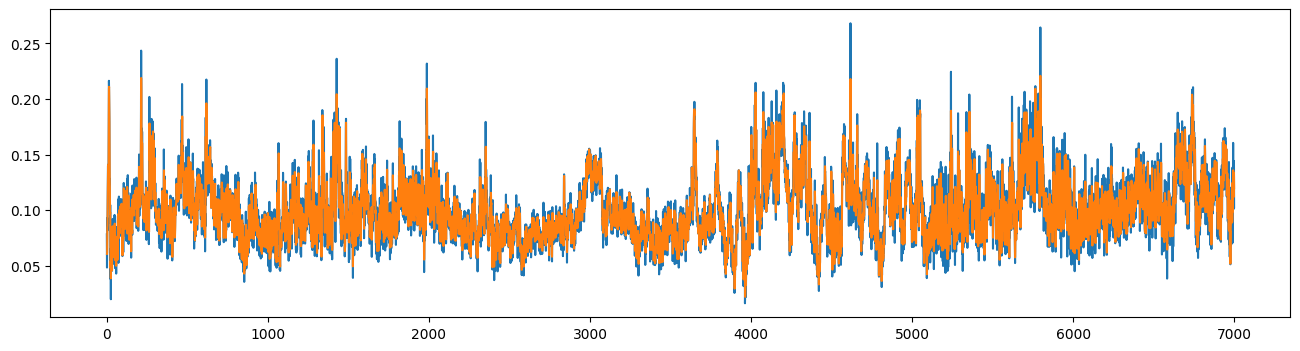

In [114]:
ix = 1000
plt.figure(figsize=(16, 4))
plt.plot(traces_official[:, ix])
# plt.plot(traces_agg[:, ix], marker="o")
plt.plot(interp[:, ix])
